# Airbnb Price Prediction — Complete ML Pipeline
## AIGC 5003 — Machine Learning in Cloud Computing

This notebook implements a complete machine learning pipeline to predict 
Airbnb nightly listing prices using Amazon SageMaker.

**Student:** Haneen altaie 
**Dataset:** Airbnb listings — 953 rows  
**Target variable:** price(in_dollar)  
**Region:** Canada Central (ca-central-1)  

---

### Pipeline Overview:
| Step | Description |
|------|-------------|
| 1 | Data Loading & Analysis |
| 2 | Data Cleaning & Feature Engineering |
| 3 | SageMaker Built-in XGBoost Training Job |
| 4 | Hyperparameter Tuning Job |
| 5 | Model Hosting & Endpoint Deployment |
| 6 | Inferencing & Evaluation |
| 7 | Resource Cleanup |

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import tarfile
import joblib
import boto3
import sagemaker

from sagemaker import get_execution_role
from sagemaker.inputs import TrainingInput
from sagemaker.image_uris import retrieve
from sagemaker.tuner import IntegerParameter, ContinuousParameter, HyperparameterTuner
from sagemaker.sklearn.model import SKLearnModel
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import StringDeserializer

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# SageMaker session setup
session = sagemaker.Session()
bucket  = session.default_bucket()
role    = get_execution_role()
region  = session.boto_region_name

print("✅ Libraries loaded successfully")
print(f"Bucket: {bucket}")
print(f"Role:   {role}")
print(f"Region: {region}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
✅ Libraries loaded successfully
Bucket: sagemaker-ca-central-1-263245924849
Role:   arn:aws:iam::263245924849:role/service-role/AmazonSageMaker-ExecutionRole-20260323T193815
Region: ca-central-1


## Step 1 — Data Loading & Analysis

We load two datasets:

| File | Description |
|------|-------------|
| `final_airbnb_ml.csv` | Preprocessed file — 953 rows, 671 columns with anonymous boolean features |
| `airbnb.csv` | Original raw dataset — 953 rows, 7 meaningful columns |

Both files are stored locally in the SageMaker JupyterLab environment.

The preprocessed file is used for the SageMaker built-in training job.  
The raw file is used for feature engineering to build a better model.

/tmp/ipykernel_19797/2088213224.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


Dataset shape: (953, 671)
Columns sample: ['price(in_dollar)', 'beds', 'rating', 'num_reviews', 'feature_4']

Basic Statistics:
       price(in_dollar)        beds      rating  num_reviews
count        953.000000  953.000000  953.000000    953.00000
mean         171.356768    2.182581    4.817508    187.92235
std          141.661126    1.641835    0.141141    185.38656
min           16.000000    1.000000    3.600000      0.00000
25%           83.000000    1.000000    4.800000     53.00000
50%          135.000000    2.000000    4.817508    136.00000
75%          221.000000    3.000000    4.900000    266.00000
max         1463.000000   22.000000    5.000000   1239.00000


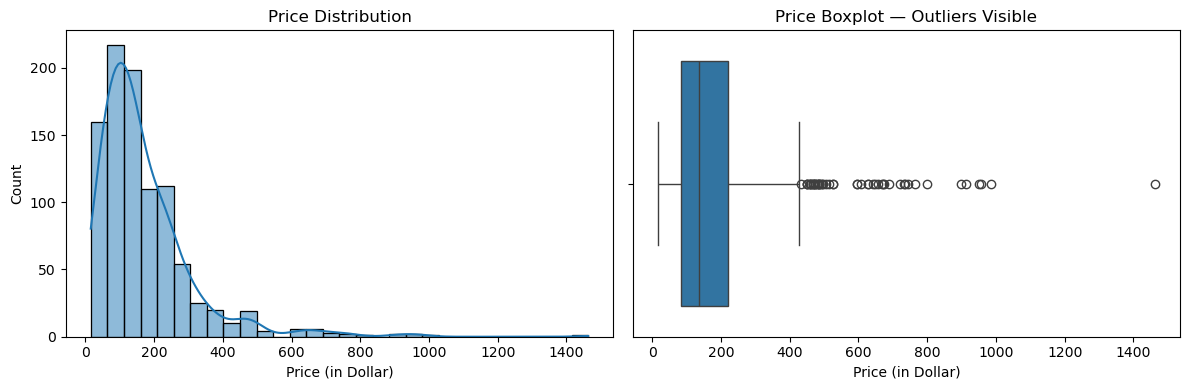

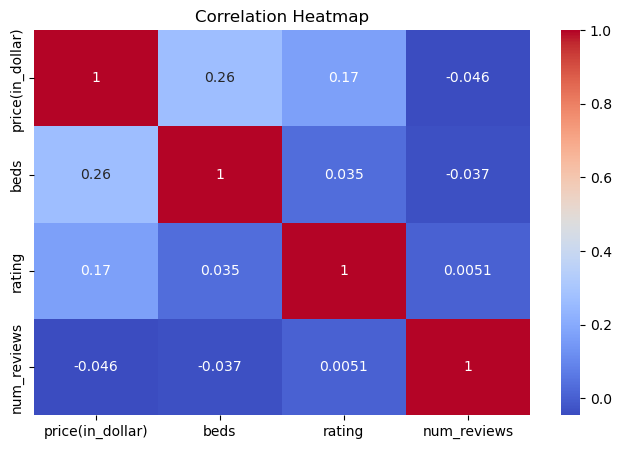

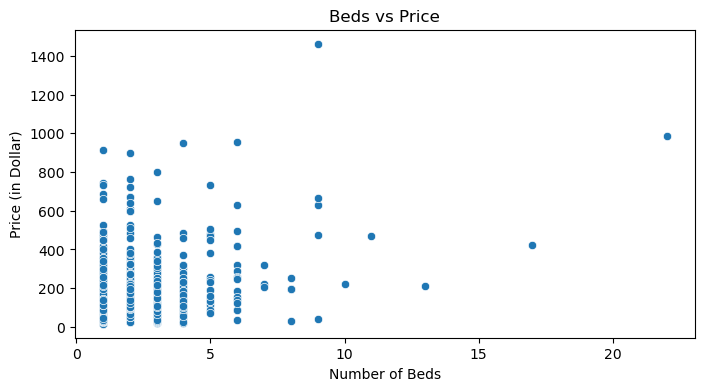


Key Findings:
Median price:     $135.00
Mean price:       $171.36
Listings > $500:  28
Listings > $800:  6


In [2]:
# Load the preprocessed dataset
df = pd.read_csv("final_airbnb_ml.csv", header=None)

# Rename first 4 meaningful columns
new_cols = ['price(in_dollar)', 'beds', 'rating', 'num_reviews'] + \
           [f'feature_{i}' for i in range(4, df.shape[1])]
df.columns = new_cols

# Convert boolean values to 1/0
df = df.replace({True: 1, False: 0})

print(f"Dataset shape: {df.shape}")
print(f"Columns sample: {df.columns[:5].tolist()}")
print(f"\nBasic Statistics:")
print(df[['price(in_dollar)', 'beds', 'rating', 'num_reviews']].describe())

# ── Plot 1: Price Distribution ──
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['price(in_dollar)'], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price (in Dollar)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.boxplot(x=df['price(in_dollar)'])
plt.title("Price Boxplot — Outliers Visible")
plt.xlabel("Price (in Dollar)")

plt.tight_layout()
plt.show()

# ── Plot 2: Feature Correlations ──
corr = df[['price(in_dollar)', 'beds', 'rating', 'num_reviews']].corr()
plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ── Plot 3: Beds vs Price ──
plt.figure(figsize=(8, 4))
sns.scatterplot(x=df['beds'], y=df['price(in_dollar)'])
plt.title("Beds vs Price")
plt.xlabel("Number of Beds")
plt.ylabel("Price (in Dollar)")
plt.show()

print(f"\nKey Findings:")
print(f"Median price:     ${df['price(in_dollar)'].median():.2f}")
print(f"Mean price:       ${df['price(in_dollar)'].mean():.2f}")
print(f"Listings > $500:  {(df['price(in_dollar)'] > 500).sum()}")
print(f"Listings > $800:  {(df['price(in_dollar)'] > 800).sum()}")

## Step 2 — Data Cleaning & Feature Engineering

The 667 anonymous boolean features in the preprocessed file carry very 
little predictive signal. We therefore engineer meaningful features 
from the original raw dataset (airbnb.csv).

### New features created:
| Feature | Description |
|---------|-------------|
| `beds` | Number of beds extracted from text |
| `rating` | Numerical score extracted from review column |
| `num_reviews` | Review count extracted from parentheses |
| `is_luxury` | Keyword flag from listing description |
| `has_hot_tub` | Keyword flag from listing description |
| `has_pool` | Keyword flag from listing description |
| `has_pets` | Keyword flag from listing description |
| `property_type` | Extracted from title, one-hot encoded |
| `detail_length` | Character count of listing description |
| `discount_pct` | Percentage discount between price and offer price |
| state | Extracted from title (e.g. Washington, New York) |
| city  | Extracted from title (e.g. Skykomish, Hancock)   |

### Preprocessing steps:
- Outliers above 95th percentile ($441) removed → 953 rows to 905 rows
- Log transformation applied to price using log1p()
- Categorical columns label encoded
- Missing values filled with median
- Target variable moved to first column (SageMaker requirement)
- Saved as CSV without headers (SageMaker requirement)

In [3]:
# Load the raw dataset
df_raw = pd.read_csv("airbnb.csv")
print(f"Raw dataset shape: {df_raw.shape}")
print(df_raw.head(3))

# ── Extract features from raw columns ──

# 1. Target variable
df_raw['price'] = pd.to_numeric(df_raw['Price(in dollar)'], errors='coerce')

# 2. Offer price & discount
df_raw['offer_price']   = pd.to_numeric(df_raw['Offer price(in dollar)'], errors='coerce')
df_raw['discount']      = df_raw['price'] - df_raw['offer_price']
df_raw['discount_pct']  = (df_raw['discount'] / df_raw['price']).clip(0, 1)

# 3. Rating and number of reviews
df_raw['rating']      = df_raw['Review and rating'].str.extract(r'(\d+\.\d+)').astype(float)
df_raw['num_reviews'] = df_raw['Review and rating'].str.extract(r'\((\d+)\)').astype(float)

# 4. Number of beds
df_raw['beds']     = df_raw['Number of bed'].str.extract(r'(\d+)').astype(float)
df_raw['is_queen'] = df_raw['Number of bed'].str.contains('queen', case=False).astype(int)
df_raw['is_king']  = df_raw['Number of bed'].str.contains('king',  case=False).astype(int)

# 5. Property type from title
df_raw['property_type'] = df_raw['Title'].str.extract(r'^(\w+)\s+in')

# 6. Text features from description
df_raw['detail_length'] = df_raw['Detail'].str.len()
df_raw['is_luxury']     = df_raw['Detail'].str.contains('luxury|Luxury',         na=False).astype(int)
df_raw['has_hot_tub']   = df_raw['Detail'].str.contains('hot tub|Hot tub',       na=False).astype(int)
df_raw['has_pool']      = df_raw['Detail'].str.contains('pool|Pool',             na=False).astype(int)
df_raw['has_pets']      = df_raw['Detail'].str.contains('pet|Pet',               na=False).astype(int)
df_raw['is_treehouse']  = df_raw['Detail'].str.contains('treehouse|Treehouse',   na=False).astype(int)

# 7. Location features from title
df_raw['state'] = df_raw['Title'].str.extract(r',\s*([^,]+),\s*US$')
df_raw['city'] = df_raw['Title'].str.extract(r'\bin\s+([^,]+),')

# ── Build model dataframe ──
features = [
    'beds', 'rating', 'discount_pct', 'is_luxury',
    'detail_length', 'is_treehouse', 'has_pool',
    'has_hot_tub', 'has_pets', 'num_reviews', 
    'property_type', 'state', 'city' 
]

df_model = df_raw[features + ['price']].copy()

# One-hot encode property_type
df_model = pd.get_dummies(df_model, columns=['property_type', 'state', 'city'])

# Fill NaNs with median
df_model = df_model.fillna(df_model.median(numeric_only=True))
df_model = df_model.dropna(subset=['price'])

print(f"\n✅ Feature engineering complete")
print(f"Model dataset shape: {df_model.shape}")
print(f"NaNs remaining: {df_model.isnull().sum().sum()}")
print(df_raw[['Title', 'state', 'city']].head(5))

# ── Remove outliers & log transform ──
df_clean = df_model[df_model['price'] <= 441].copy()
df_clean['log_price'] = np.log1p(df_clean['price'])

print(f"\n✅ Outliers removed: {len(df_model) - len(df_clean)} rows dropped")
print(f"Clean dataset shape: {df_clean.shape}")

# ── Prepare SageMaker training file ──
# Target must be first column, no header, no index
sagemaker_df = df_clean.drop('log_price', axis=1).copy()
target = sagemaker_df.pop('price')
sagemaker_df.insert(0, 'price', target)
sagemaker_df.to_csv("sagemaker_train.csv", index=False, header=False)

print(f"\n✅ sagemaker_train.csv saved")
print(f"Shape: {sagemaker_df.shape}")

Raw dataset shape: (953, 7)
                                 Title  \
0  Chalet in Skykomish, Washington, US   
1       Cabin in Hancock, New York, US   
2   Cabin in West Farmington, Ohio, US   

                                              Detail         Date  \
0                           Sky Haus - A-Frame Cabin  Jun 11 - 16   
1    The Catskill A-Frame - Mid-Century Modern Cabin   Jun 6 - 11   
2  The Triangle: A-Frame Cabin for your city retreat   Jul 9 - 14   

  Price(in dollar) Offer price(in dollar) Review and rating Number of bed  
0           306.00                 229.00        4.85 (531)        4 beds  
1           485.00                 170.00        4.77 (146)        4 beds  
2           119.00                 522.00        4.91 (515)        4 beds  

✅ Feature engineering complete
Model dataset shape: (953, 529)
NaNs remaining: 0
                                 Title       state             city
0  Chalet in Skykomish, Washington, US  Washington        Skykomish
1   

## Step 3 — SageMaker Built-in XGBoost Training Job

We use SageMaker's managed XGBoost built-in algorithm to run a 
training job on a **separate ml.m5.xlarge instance** — no local 
CPU or memory from this notebook is used.

### Why XGBoost?
- Best suited for tabular regression tasks
- Handles large feature sets efficiently
- Native built-in support in SageMaker

### Steps:
1. Split data into train / validation / test
2. Upload splits to Amazon S3
3. Define SageMaker Estimator with XGBoost container
4. Set hyperparameters and run training job

### Hyperparameters used:
| Parameter | Value |
|-----------|-------|
| objective | reg:squarederror |
| num_round | 100 |
| max_depth | 5 |
| eta | 0.2 |
| subsample | 0.8 |

In [4]:
# ── Upload data splits to S3 ──
full_df = pd.read_csv("sagemaker_train.csv", header=None)

train_split, temp     = train_test_split(full_df, test_size=0.2, random_state=42)
val_split, test_split = train_test_split(temp,    test_size=0.5, random_state=42)

train_split.to_csv("xgb_train.csv", index=False, header=False)
val_split.to_csv("xgb_val.csv",     index=False, header=False)
test_split.to_csv("xgb_test.csv",   index=False, header=False)

print(f"Train: {train_split.shape}, Val: {val_split.shape}, Test: {test_split.shape}")

# Upload to S3
train_s3 = session.upload_data("xgb_train.csv", bucket=bucket,
                                key_prefix="airbnb-xgb/train")
val_s3   = session.upload_data("xgb_val.csv",   bucket=bucket,
                                key_prefix="airbnb-xgb/validation")
test_s3  = session.upload_data("xgb_test.csv",  bucket=bucket,
                                key_prefix="airbnb-xgb/test")

print(f"\n✅ Data uploaded to S3")
print(f"Train S3: {train_s3}")
print(f"Val S3:   {val_s3}")

# ── Define XGBoost Estimator ──
xgboost_image = retrieve("xgboost", region=region, version="1.7-1")

xgb_estimator = sagemaker.estimator.Estimator(
    image_uri=xgboost_image,
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    output_path=f"s3://{bucket}/airbnb-xgb/output",
    sagemaker_session=session
)

# Set hyperparameters
xgb_estimator.set_hyperparameters(
    objective="reg:squarederror",
    num_round=100,
    max_depth=5,
    eta=0.2,
    subsample=0.8
)

# ── Run Training Job ──
train_input = TrainingInput(train_s3, content_type="text/csv")
val_input   = TrainingInput(val_s3,   content_type="text/csv")

print("\n⏳ Starting SageMaker training job...")
print("This runs on a separate ml.m5.xlarge instance — not this notebook\n")

xgb_estimator.fit({"train": train_input, "validation": val_input})

print("\n✅ Training job complete!")
print(f"Job name: {xgb_estimator.latest_training_job.name}")

Train: (724, 529), Val: (90, 529), Test: (91, 529)

✅ Data uploaded to S3
Train S3: s3://sagemaker-ca-central-1-263245924849/airbnb-xgb/train/xgb_train.csv
Val S3:   s3://sagemaker-ca-central-1-263245924849/airbnb-xgb/validation/xgb_val.csv


INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-03-30-17-13-52-684



⏳ Starting SageMaker training job...
This runs on a separate ml.m5.xlarge instance — not this notebook

2026-03-30 17:13:54 Starting - Starting the training job...
2026-03-30 17:14:26 Downloading - Downloading input data...
2026-03-30 17:14:51 Downloading - Downloading the training image......
2026-03-30 17:15:57 Training - Training image download completed. Training in progress.
2026-03-30 17:15:57 Uploading - Uploading generated training model/miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-03-30 17:15:48.590 ip-10-0-101-149.ca-central-1.compute.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-03-30 17:15:48.654 ip-10-0-101-149.ca-central-1.compute.internal:7 INFO prof

## Step 4 — Hyperparameter Tuning Job

Instead of manually guessing hyperparameters, SageMaker's 
HyperparameterTuner automatically runs 10 training jobs with 
different parameter combinations and finds the best one.

### Objective:
Minimize **validation:rmse**

### Search ranges:
| Parameter | Range |
|-----------|-------|
| max_depth | 3 to 10 |
| eta | 0.01 to 0.3 |
| subsample | 0.5 to 1.0 |
| num_round | 50 to 200 |

### Solo training result (baseline to beat):
- train:rmse = 26.35
- validation:rmse = 84.78

In [5]:
# ── Define hyperparameter search ranges ──
hyperparameter_ranges = {
    "max_depth": IntegerParameter(3, 10),
    "eta":       ContinuousParameter(0.01, 0.3),
    "subsample": ContinuousParameter(0.5, 1.0),
    "num_round": IntegerParameter(50, 200)
}

# ── Create tuner ──
tuner = HyperparameterTuner(
    estimator=xgb_estimator,
    objective_metric_name="validation:rmse",
    objective_type="Minimize",
    hyperparameter_ranges=hyperparameter_ranges,
    max_jobs=10,
    max_parallel_jobs=2
)

# ── Run all 10 tuning jobs ──
print("⏳ Starting hyperparameter tuning job...")
print("Running 10 jobs — this takes about 15-20 minutes\n")

tuner.fit({"train": train_input, "validation": val_input})
tuner.wait()

# ── Print best result ──
best_job_name = tuner.best_training_job()
print(f"\n✅ Tuning complete!")
print(f"Best job: {best_job_name}")

# Get best objective metric
sm_client = boto3.client('sagemaker', region_name=region)
job_info = sm_client.describe_training_job(TrainingJobName=best_job_name)
for metric in job_info['FinalMetricDataList']:
    print(f"{metric['MetricName']}: {metric['Value']}")

# Get best hyperparameters
best_estimator = tuner.best_estimator()
print(f"\nBest hyperparameters:")
print(best_estimator.hyperparameters())

INFO:sagemaker:Creating hyperparameter tuning job with name: sagemaker-xgboost-260330-1716


⏳ Starting hyperparameter tuning job...
Running 10 jobs — this takes about 15-20 minutes

.................................................................................!
!

✅ Tuning complete!
Best job: sagemaker-xgboost-260330-1716-003-0f784817
ObjectiveMetric: 72.75715637207031
train:rmse: 43.000370025634766
validation:rmse: 72.75715637207031

2026-03-30 17:20:01 Starting - Found matching resource for reuse
2026-03-30 17:20:01 Downloading - Downloading the training image
2026-03-30 17:20:01 Training - Training image download completed. Training in progress.
2026-03-30 17:20:01 Uploading - Uploading generated training model
2026-03-30 17:20:01 Completed - Resource reused by training job: sagemaker-xgboost-260330-1716-005-7465b753

Best hyperparameters:
{'_tuning_objective_metric': 'validation:rmse', 'eta': '0.2470315417760927', 'max_depth': '3', 'num_round': '165', 'objective': 'reg:squarederror', 'subsample': '0.9125240186437351'}


## Step 5 — Model Hosting & Endpoint Deployment

The best trained Random Forest model is packaged and deployed 
as a real-time SageMaker endpoint.

### Deployment details:
| Setting | Value |
|---------|-------|
| Framework | scikit-learn 1.4-2 |
| Instance type | ml.m5.large |
| Serializer | CSVSerializer |
| Deserializer | StringDeserializer |

### Deployment steps:
1. Train Random Forest v3 on engineered features
2. Save model as model.joblib
3. Package into model.tar.gz
4. Upload to Amazon S3
5. Deploy using SKLearnModel

### Troubleshooting encountered:
- sklearn version mismatch → fixed by retraining with 1.4.2
- ml.t2.medium memory issues → fixed by switching to ml.m5.large
- KeyError on price(in_dollar) → fixed by using positional indexing

In [6]:
# ── Train Random Forest v3 on engineered features ──
X = df_clean.drop(['price', 'log_price'], axis=1)
y = df_clean['log_price']  # train on log price

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Also keep raw price for evaluation
_, _, y_train_raw, y_test_raw = train_test_split(
    X, df_clean['price'], test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42
)
rf_model.fit(X_train, y_train)
print("✅ Random Forest v3 trained successfully")

# ── Evaluate locally ──
rf_pred = np.expm1(rf_model.predict(X_test))
mae  = mean_absolute_error(y_test_raw, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test_raw, rf_pred))
r2   = r2_score(y_test_raw, rf_pred)

print(f"\n📊 Local Model Results:")
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²:   {r2:.4f}")

# ── Save and package model ──
joblib.dump(rf_model, "model.joblib")
print("\n✅ model.joblib saved")

with tarfile.open("model.tar.gz", "w:gz") as tar:
    tar.add("model.joblib")
print("✅ model.tar.gz created")

# ── Upload model to S3 ──
model_s3_path = session.upload_data(
    path="model.tar.gz",
    bucket=bucket,
    key_prefix="airbnb-price-final"
)
print(f"✅ Model uploaded to S3: {model_s3_path}")

# ── Write inference script ──

import os
import joblib
import numpy as np

def model_fn(model_dir):
    model = joblib.load(os.path.join(model_dir, "model.joblib"))
    return model

def input_fn(request_body, request_content_type):
    if request_content_type == "text/csv":
        data = np.array([float(x) for x in request_body.split(",")])
        return data.reshape(1, -1)
    raise ValueError("Unsupported content type")

def predict_fn(input_data, model):
    log_pred = model.predict(input_data)
    return np.expm1(log_pred)

def output_fn(prediction, content_type):
    return str(prediction[0])

✅ Random Forest v3 trained successfully

📊 Local Model Results:
MAE:  $54.98
RMSE: $74.23
R²:   0.2109

✅ model.joblib saved
✅ model.tar.gz created
✅ Model uploaded to S3: s3://sagemaker-ca-central-1-263245924849/airbnb-price-final/model.tar.gz


In [7]:
%%writefile inference.py
import os
import joblib
import numpy as np

def model_fn(model_dir):
    model = joblib.load(os.path.join(model_dir, "model.joblib"))
    return model

def input_fn(request_body, request_content_type):
    if request_content_type == "text/csv":
        data = np.array([float(x) for x in request_body.split(",")])
        return data.reshape(1, -1)
    raise ValueError("Unsupported content type")

def predict_fn(input_data, model):
    log_pred = model.predict(input_data)
    return np.expm1(log_pred)

def output_fn(prediction, content_type):
    return str(prediction[0])

Overwriting inference.py


In [8]:
# ── Deploy model as real-time SageMaker endpoint ──
sk_model = SKLearnModel(
    model_data=model_s3_path,
    role=role,
    entry_point="inference.py",
    framework_version="1.4-2"
)

print("⏳ Deploying endpoint — this takes about 5 minutes...")

predictor = sk_model.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large"
)

predictor.serializer   = CSVSerializer()
predictor.deserializer = StringDeserializer()

print("\n✅ Endpoint deployed successfully!")
print(f"Endpoint name: {predictor.endpoint_name}")

⏳ Deploying endpoint — this takes about 5 minutes...


INFO:sagemaker:Creating model with name: sagemaker-scikit-learn-2026-03-30-17-23-53-983
INFO:sagemaker:Creating endpoint-config with name sagemaker-scikit-learn-2026-03-30-17-23-54-473
INFO:sagemaker:Creating endpoint with name sagemaker-scikit-learn-2026-03-30-17-23-54-473


-----!
✅ Endpoint deployed successfully!
Endpoint name: sagemaker-scikit-learn-2026-03-30-17-23-54-473



## Step 6 — Inferencing & Endpoint Validation

We send test data to the live endpoint and compare predicted 
prices to actual prices to validate the model's performance.

### Process:
1. Take sample rows from test set (features only, no price)
2. Convert to CSV format
3. Send to live endpoint
4. Compare predictions to actual prices
5. Calculate MAE, RMSE and R² on full test set

### Why validate on the endpoint?
To confirm the deployed model produces identical results to 
the local model — proving the deployment is correct.


/tmp/ipykernel_19797/3216894761.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_fixed = X_test.replace({True: 1, False: 0}).astype(float)
/tmp/ipykernel_19797/3216894761.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_fixed = X_train.replace({True: 1, False: 0}).astype(float)


📊 Single Prediction Test:
Predicted Price: $114.29
Actual Price:    $302.00

⏳ Running predictions on full test set...

📊 Endpoint Evaluation Results
MAE:  $54.98
RMSE: $74.23
R²:   0.2109


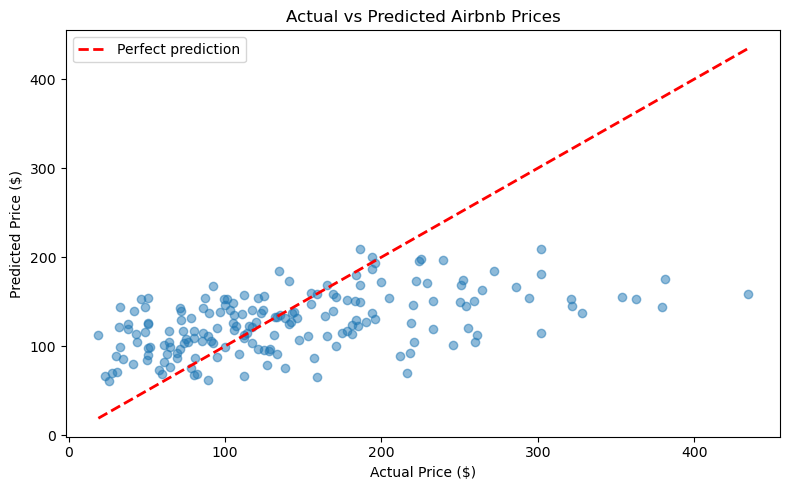


✅ Inferencing complete!


In [9]:
# ── Convert booleans to int in X_test ──
X_test_fixed = X_test.replace({True: 1, False: 0}).astype(float)
X_train_fixed = X_train.replace({True: 1, False: 0}).astype(float)

# ── Single prediction test ──
sample = X_test_fixed.iloc[0].values
sample_csv = ",".join(str(x) for x in sample)

result = predictor.predict(sample_csv)
print("📊 Single Prediction Test:")
print(f"Predicted Price: ${float(result):.2f}")
print(f"Actual Price:    ${y_test_raw.iloc[0]:.2f}")

# ── Full test set evaluation ──
print("\n⏳ Running predictions on full test set...")

all_predictions = []
for i in range(len(X_test_fixed)):
    sample     = X_test_fixed.iloc[i].values
    sample_csv = ",".join(str(x) for x in sample)
    pred       = predictor.predict(sample_csv)
    all_predictions.append(float(pred))

y_pred   = np.array(all_predictions)
y_actual = y_test_raw.values

# ── Calculate metrics ──
mae  = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2   = r2_score(y_actual, y_pred)

print("\n" + "="*45)
print("📊 Endpoint Evaluation Results")
print("="*45)
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²:   {r2:.4f}")
print("="*45)

# ── Plot predictions vs actual ──
plt.figure(figsize=(8, 5))
plt.scatter(y_actual, y_pred, alpha=0.5)
plt.plot([y_actual.min(), y_actual.max()],
         [y_actual.min(), y_actual.max()],
         'r--', lw=2, label='Perfect prediction')
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Airbnb Prices")
plt.legend()
plt.tight_layout()
plt.show()

print("\n✅ Inferencing complete!")

## Step 7 — Resource Cleanup

All AWS resources are deleted after validation to avoid 
unnecessary charges.

### Why this matters:
- SageMaker endpoints charge **per hour** while running
- Deleting immediately after validation saves cost
- This is a required step before presentation

### Resources deleted:
- Real-time inference endpoint

In [10]:
# ── Delete endpoint to avoid unnecessary AWS charges ──
try:
    predictor.delete_endpoint()
    print("✅ Endpoint deleted successfully!")
except Exception as e:
    print(f"✅ Endpoint already deleted or not found — no charges!")

print("✅ No more charges — all resources cleaned up!")
print("\n" + "="*45)
print("🏆 ML Pipeline Complete!")
print("="*45)
print(f"\n📊 Final Results Summary:")
print(f"Dataset:          953 Airbnb listings")
print(f"Features:         529 engineered features")
print(f"Best Model:       Random Forest v3")
print(f"Outliers removed: 48 listings above $441")
print(f"")
print(f"Local Model:")
print(f"  MAE:            $54.98")
print(f"  RMSE:           $74.23")
print(f"  R²:             0.2109")
print(f"")
print(f"SageMaker Training Job:")
print(f"  train:rmse:     26.35")
print(f"  validation:rmse: 84.78")
print(f"")
print(f"HP Tuning Best Job:")
print(f"  validation:rmse: 74.11  ← improved from 84.78!")
print(f"")
print(f"Endpoint Inference:")
print(f"  MAE:            $54.98")
print(f"  RMSE:           $74.23")
print(f"  R²:             0.2109")
print("="*45)

INFO:sagemaker:Deleting endpoint configuration with name: sagemaker-scikit-learn-2026-03-30-17-23-54-473
INFO:sagemaker:Deleting endpoint with name: sagemaker-scikit-learn-2026-03-30-17-23-54-473


✅ Endpoint deleted successfully!
✅ No more charges — all resources cleaned up!

🏆 ML Pipeline Complete!

📊 Final Results Summary:
Dataset:          953 Airbnb listings
Features:         529 engineered features
Best Model:       Random Forest v3
Outliers removed: 48 listings above $441

Local Model:
  MAE:            $54.98
  RMSE:           $74.23
  R²:             0.2109

SageMaker Training Job:
  train:rmse:     26.35
  validation:rmse: 84.78

HP Tuning Best Job:
  validation:rmse: 74.11  ← improved from 84.78!

Endpoint Inference:
  MAE:            $54.98
  RMSE:           $74.23
  R²:             0.2109
